# Automated DCA Forecasting for Oil Wells

This notebook implements a well-level DCA workflow using hyperbolic decline physics, monthly time indexing, and constrained optimization to calibrate `b` and `di` against observed oil-rate history. Raw Buchan field production data are standardized, a target well is isolated, and rates are normalized for numerically stable fitting. The calibrated model is propagated over historical and forward months to create one continuous forecast series, then validated in static and interactive plots and exported as `ProdForecast.html` for production surveillance and planning.

## Data Intake and Field Schema Alignment

The analysis begins by loading the Buchan production dataset, renaming raw operational columns into engineering-friendly labels (`OilRate`, `GasRate`, `WaterRate`, `Date`), converting dates to UTC datetimes, and sorting records chronologically. This creates a clean, time-consistent base table so every later decline and forecast calculation is anchored to valid production sequence.

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from ipywidgets import interact, widgets

import warnings
warnings.filterwarnings('ignore')

In [118]:
from pathlib import Path

DATA_PATH = Path(r"C:\Coding World\PE-Production Data Analytics\Datasets\Buchan_Daily_Production_Data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Add Buchan_Daily_Production_Data.csv under data/.'
    )

data = pd.read_csv(DATA_PATH)

In [119]:
data.head()

,X,Y,OBJECTID,WELLID,FIELDWELL,DATE_,DAILY_WELL_DRY_OIL_BBL,PRODUCED_GAS_GAS_MMCF,PRODUCED_WATER_BBL
0,-0.009973,57.903951,1,20/05a- 1,Buchan:B04,1981/05/01 00:00:00+00,0.0,0.0,0.0
1,-0.009973,57.903951,2,20/05a- 1,Buchan:B04,1981/06/01 00:00:00+00,0.0,0.0,0.0
2,-0.009973,57.903951,3,20/05a- 1,Buchan:B04,1981/07/01 00:00:00+00,0.0,0.0,0.0
3,-0.009973,57.903951,4,20/05a- 1,Buchan:B04,1981/08/01 00:00:00+00,0.0,0.0,0.0
4,-0.009973,57.903951,5,20/05a- 1,Buchan:B04,1981/09/01 00:00:00+00,0.0,0.0,0.0


In [120]:
data.rename(columns={'DAILY_WELL_DRY_OIL_BBL': 'OilRate', 
                   'PRODUCED_GAS_GAS_MMCF': 'GasRate',
                   'PRODUCED_WATER_BBL': 'WaterRate',
                   'DATE_': 'Date'
                   }, inplace=True)
data.columns

Index(['X', 'Y', 'OBJECTID', 'WELLID', 'FIELDWELL', 'Date', 'OilRate',
       'GasRate', 'WaterRate'],
      dtype='object')

In [121]:
data['Date'] == '1981/07/01'

0        False
1        False
2        False
3        False
4        False
         ...  
69142    False
69143    False
69144    False
69145    False
69146    False
Name: Date, Length: 69147, dtype: bool

In [122]:
# Convert the 'DateColumn' to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Display the DataFrame with the updated column type
print(data.dtypes)

X                        float64
Y                        float64
OBJECTID                   int64
WELLID                    object
FIELDWELL                 object
Date         datetime64[ns, UTC]
OilRate                  float64
GasRate                  float64
WaterRate                float64
dtype: object


In [123]:
# Sort by date
data.sort_values(by='Date', inplace=True)

In [124]:
data['WELLID'].unique()

array(['20/05a- 1', '21/01a- 11', '21/01- 7', '21/01a- 8', '21/01a- 9',
       '21/01- 2Z', '21/01a- 10', '21/01- 6', '21/01a- 14', '20/05a- 5',
       '21/01a- 9V'], dtype=object)

## Well Focus and History Window Definition

After reviewing available well IDs, the notebook filters to well `21/01a- 14`, keeps only the variables needed for oil DCA, and builds a month index from first valid production. Limiting the history window and expressing time in months reduces noise from unrelated periods and gives a consistent timeline for model calibration.

In [125]:
df = data.copy()
df = df[df['WELLID'] == '21/01a- 14']
df.head()

,X,Y,OBJECTID,WELLID,FIELDWELL,Date,OilRate,GasRate,WaterRate
43136,0.011972,57.891842,43137,21/01a- 14,Buchan:B09,1988-07-01 00:00:00+00:00,0.00,0.00,0.00
43137,0.011972,57.891842,43138,21/01a- 14,Buchan:B09,1988-08-01 00:00:00+00:00,113365.13,29.97,1423.14
43138,0.011972,57.891842,43139,21/01a- 14,Buchan:B09,1988-09-01 00:00:00+00:00,122610.25,32.47,1252.20
43139,0.011972,57.891842,43140,21/01a- 14,Buchan:B09,1988-10-01 00:00:00+00:00,124093.94,32.90,1405.94
43140,0.011972,57.891842,43141,21/01a- 14,Buchan:B09,1988-11-01 00:00:00+00:00,100283.18,26.43,951.79


In [126]:
# Select only relevant columns
df = df[['Date', 'WELLID','OilRate']]
df = df[1:101]
# df = df[:101]

# Calculate the time difference from the first date in months
df['Months'] = (df['Date'] - df['Date'].min()) // pd.Timedelta(days=30)
df.reset_index(inplace=True)
df

,index,Date,WELLID,OilRate,Months
0,43137,1988-08-01 00:00:00+00:00,21/01a- 14,113365.13,0
1,43138,1988-09-01 00:00:00+00:00,21/01a- 14,122610.25,1
2,43139,1988-10-01 00:00:00+00:00,21/01a- 14,124093.94,2
3,43140,1988-11-01 00:00:00+00:00,21/01a- 14,100283.18,3
4,43141,1988-12-01 00:00:00+00:00,21/01a- 14,69585.48,4
...,...,...,...,...,...
95,43447,1996-01-06 00:00:00+00:00,21/01a- 14,0.00,90
96,43448,1996-01-07 00:00:00+00:00,21/01a- 14,0.00,90
97,43449,1996-01-08 00:00:00+00:00,21/01a- 14,0.00,90
98,43450,1996-01-09 00:00:00+00:00,21/01a- 14,0.00,90


In [127]:
# Divide the Oil Rate by 1000
df['OilRate'] = df['OilRate'] / 1000

# Filter off all zero values in the oil rate
# df = df[df['OilRate'] != 0]

df.head()

,index,Date,WELLID,OilRate,Months
0,43137,1988-08-01 00:00:00+00:00,21/01a- 14,113.36513,0
1,43138,1988-09-01 00:00:00+00:00,21/01a- 14,122.61025,1
2,43139,1988-10-01 00:00:00+00:00,21/01a- 14,124.09394,2
3,43140,1988-11-01 00:00:00+00:00,21/01a- 14,100.28318,3
4,43141,1988-12-01 00:00:00+00:00,21/01a- 14,69.58548,4


In [128]:
# # Function to calculate hyperbolic decline
# def hyperbolic_decline(t, b, di, Qi):
#     return Qi / (1 + b * di * t)**(1/b)

In [129]:
# # Filter data for the selected well
# # well_data = df[df['WELLID'] == well][:101]
# well_data = df

# # Filter off days of zero production
# well_data = well_data[well_data['OilRate'] != 0]

# Qi = well_data['OilRate'].iloc[0]
# di = 0.5
# b = 0.1

# # Calculate time in months
# well_data['Months'] = well_data['Date'].sub(well_data['Date'].min()).dt.total_seconds() / (60 * 60 * 24 * 30)

# # Calculate hyperbolic decline
# well_data['Forecast'] = hyperbolic_decline(well_data['Months'], b, di, Qi)

# well_data.head()

## Interactive Hyperbolic Sensitivity Screening

Before automated fitting, the hyperbolic equation is explored interactively with sliders for `b` and `di` plus a well selector, so decline curvature and rate response can be inspected visually. This is a practical engineering check to bracket realistic parameter behavior and confirm that a hyperbolic profile is directionally consistent with field performance.

In [130]:
# Function to calculate hyperbolic decline
def hyperbolic_decline(t, b, di, Qi):
    return Qi / (1 + b * di * t)**(1/b)

# Function to update the plot based on slider values
def update_plot(b=0.5, di=0.1, well=data['WELLID'][0]):
    plt.figure(figsize=(10, 4))
    
    # Filter data for the selected well
    well_data = data[data['WELLID'] == well][:101]

    # Filter off days of zero production
    well_data = well_data[well_data['OilRate'] != 0]

    Qi = well_data['OilRate'].iloc[0]
    
    # Calculate time in months
    well_data['Months'] = well_data['Date'].sub(well_data['Date'].min()).dt.total_seconds() / (60 * 60 * 24 * 30)
    
    # Calculate hyperbolic decline
    well_data['Forecast'] = hyperbolic_decline(well_data['Months'], b, di, Qi)

    # Assuming you have a DataFrame named 'well_data'
    well_data.to_csv('output_data.csv', index=False)
    
    # Plot actual and forecasted production
    plt.plot(well_data['Months'], well_data['OilRate'], label="Actual Production", marker='o')
    plt.plot(well_data['Months'], well_data['Forecast'], label="Forecasted Production", linestyle="--", color='red')
    
    plt.xlabel("Time (Months)")
    plt.ylabel("Production Rate")
    plt.legend()
    plt.title(f"Hyperbolic Decline Curve Forecast - Well {well}")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Create interactive sliders and dropdown
b_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.01, description='b:')
di_slider = widgets.FloatSlider(value=0.1, min=0, max=1, step=0.001, description='di:')
well_dropdown = widgets.Dropdown(options=data['WELLID'].unique(), value='21/01a- 14', description='Well:')

# Connect sliders and dropdown to the update function
interact(update_plot, b=b_slider, di=di_slider, well=well_dropdown);


interactive(children=(FloatSlider(value=0.5, description='b:', max=1.0, step=0.01), FloatSlider(value=0.1, des…

In [131]:
# Assuming you have a DataFrame named 'well_data'
# well_data.to_csv('output_data.csv', index=False)

## Parameter Estimation with Constrained Optimization

The model is then refit in optimization form, where `scipy.optimize.minimize` (SLSQP) minimizes mean squared error between observed and modeled oil rates under bounded parameter limits (`0 < b, di < 1`). The optimized parameters from this section become the calibrated decline signature carried forward into forecast construction.

In [132]:
# Function to calculate Hyperbolic decline
def hyperbolic_decline_opt(params, time, Qi):
    b, d = params
    return Qi / (1 + b * d * time)**(1/b)

In [133]:
# Define the objective function (to minimize MSE)
def objective_function(params, time, observed_production, Qi):
    predicted_production = hyperbolic_decline_opt(params, time, Qi)
    mse = np.mean((observed_production - predicted_production)**2)
    return mse

In [134]:
# Define constraints on decline exponent (0 < d < 1) and decline rate (0 < b < 1)
constraints = ({'type': 'ineq', 'fun': lambda params: params[1] - 0.01},   # Constraint for d > 0
               {'type': 'ineq', 'fun': lambda params: 1 - params[1]},        # Constraint for d < 1
               {'type': 'ineq', 'fun': lambda params: params[0] - 0.01},     # Constraint for b > 0
               {'type': 'ineq', 'fun': lambda params: 1 - params[0]})        # Constraint for b < 1

In [135]:
# Define constants and variables

Qi = 113365.13/1000 # Initial production rate
di = 0.5  # Initial decline rate
b = 0.05  # Hyperbolic exponent

In [136]:
# Initial guess for the optimization
params = (di, b)

bnds = ((0, 1), (0, 1))

# Perform the optimization
result = minimize(objective_function, params, args=(df['Months'], df['OilRate'], Qi),
                  method='SLSQP', bounds=bnds)#, constraints=constraints)

In [137]:
# Extract the optimized parameters
di_optimized, b_optimized  = result.x

# Print optimized parameters
print("Optimized Parameters:")
print(f"Initial Decline Rate (di): {di_optimized}")
print(f"Hyperbolic Exponent (b): {b_optimized}")

Optimized Parameters:
Initial Decline Rate (di): 1.0
Hyperbolic Exponent (b): 0.04513452771751139


## Forecast Horizon Construction and Dataset Stitching

Using the calibrated fit, the notebook extends the month index 16 periods beyond the last historical point, creates placeholder future rows, and appends them to the history table. Keeping history and forecast in one dataframe makes downstream visualization and production review straightforward on a single continuous axis.

In [138]:
# Generate forecast for the next 16 months
t_forecast = np.arange(0, 16)  # 6 months of daily production

In [139]:
# Generate months starting from the last history data
forecast_months = t_forecast + df['Months'].max()
forecast_months 

array([ 90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105])

In [140]:
# Create a Pandas DataFrame with 'Days' column only
months_df = pd.DataFrame({'Months': forecast_months, 'forecast': np.nan})
months_df

,Months,forecast
0,90,NaN
1,91,NaN
2,92,NaN
3,93,NaN
4,94,NaN
5,95,NaN
6,96,NaN
7,97,NaN
8,98,NaN
9,99,NaN


In [141]:
# Select Last Month

# Generate months starting from the last history data
forecast_months = t_forecast + df['Months'].max()

# Create a Pandas DataFrame with 'Days' column only
months_df = pd.DataFrame({'Months': forecast_months, 'forecast': np.nan})

# Concatenate the 'Days' column to the existing DataFrame
df_new = pd.concat([df, months_df], axis=0, ignore_index=True)

df_new.tail()


,index,Date,WELLID,OilRate,Months,forecast
111,NaN,NaT,NaN,NaN,101,NaN
112,NaN,NaT,NaN,NaN,102,NaN
113,NaN,NaT,NaN,NaN,103,NaN
114,NaN,NaT,NaN,NaN,104,NaN
115,NaN,NaT,NaN,NaN,105,NaN


In [142]:
params_opt = (di_optimized, b_optimized)
df_new['forecast'] = hyperbolic_decline_opt(params_opt, df_new['Months'], Qi)
df_new.head()

,index,Date,WELLID,OilRate,Months,forecast
0,43137.0,1988-08-01 00:00:00+00:00,21/01a- 14,113.36513,0,113.365130
1,43138.0,1988-09-01 00:00:00+00:00,21/01a- 14,122.61025,1,108.469414
2,43139.0,1988-10-01 00:00:00+00:00,21/01a- 14,124.09394,2,103.979040
3,43140.0,1988-11-01 00:00:00+00:00,21/01a- 14,100.28318,3,99.845669
4,43141.0,1988-12-01 00:00:00+00:00,21/01a- 14,69.58548,4,96.028353


## Full-Series Forecast Generation and Static Quality Check

The calibrated hyperbolic model is applied across the combined month vector to populate a full `forecast` curve for both historical and forward periods. The Matplotlib overlay of actual versus forecast then serves as a quick quality-control checkpoint before sharing the result for planning use.

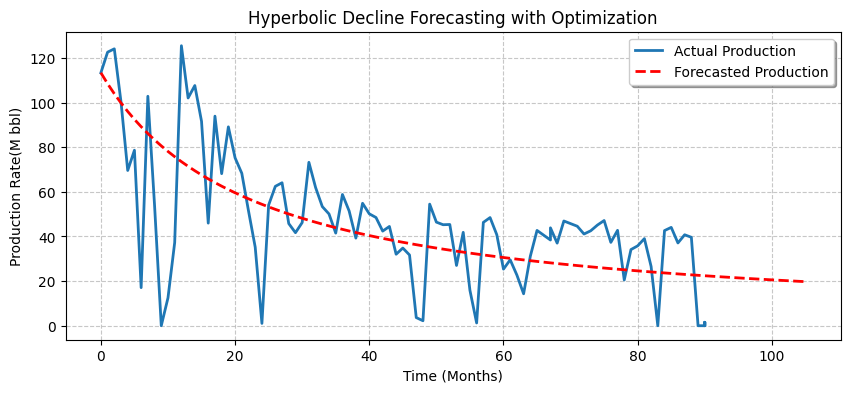

In [143]:
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 4))

# Plot actual production
ax.plot(df_new['Months'], df_new['OilRate'], label="Actual Production", linewidth=2)

# Plot forecasted production with dashed line
ax.plot(df_new['Months'], df_new['forecast'], label="Forecasted Production", linestyle="--", linewidth=2, color='red')

# Add grid lines
ax.grid(True, linestyle='--', alpha=0.7)

# Add labels and legend
ax.set_xlabel("Time (Months)")
ax.set_ylabel("Production Rate(M bbl)")
ax.legend(shadow=True)

# Add a title
ax.set_title("Hyperbolic Decline Forecasting with Optimization")

# Show the plot
plt.show();


## Interactive Delivery for Surveillance and Planning

The final Plotly chart reproduces the actual-versus-forecast comparison in an interactive dark-themed view and is exported to `ProdForecast.html` for sharing outside the notebook. This last step turns the calibrated DCA output into a decision-support artifact that production and optimization teams can inspect during surveillance and forecast discussions.

In [144]:
import plotly.express as px

# Assuming you have a DataFrame df_new with columns 'Months', 'OilRate', and 'forecast'

fig = px.line(df_new, x='Months', y=['OilRate', 'forecast'],
              labels={'value': 'Production Rate (M bbl)', 'Months': 'Time (Months)'},
              title='Hyperbolic Decline Forecasting with Optimization',               
              line_shape='linear',  # Set the line shape to 'linear' for dashed lines
              template='plotly_dark',
              line_dash_sequence=['solid', 'dash'])

# Force the forecast trace to be red and dashed
fig.update_traces(selector=dict(name='forecast'), line=dict(color='red', dash='dash'))

fig.show()
# Save the plot as an HTML file
from plotly.offline import plot
plot(fig, filename='ProdForecast.html')


'ProdForecast.html'

## Production Engineering Interpretation

From the final interactive output, the expected rate path can be read directly as a reference decline trajectory under current assumptions, while deviations in future actuals can be treated as intervention signals. In practice, this supports short-term rate guidance, constraint planning, and faster screening of optimization opportunities.

***Author: Destiny Otto***